In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from tqdm import tqdm
from scipy.stats import linregress
from ipywidgets import interact, FloatSlider

from importlib import reload
from voter_model import solution_fpt as fpt
from voter_model import utils as ut

fpt = reload(fpt)
ut = reload(ut)

# First Passage Times

We want to get the simulated first passage time distribution

In [2]:
@njit
def init_config(N, m0):
    """Initializes configuration"""
    n_up = int(N * (1 + m0) / 2)
    
    r = np.full(N, -1, dtype=np.int8)
    r[:n_up] = 1
    return r
    

@njit
def first_passage_time(N, m0, r):
    '''Takes:
    N: number of agents
    r: resetting rate per MC step
    m0: starting magnetisation
    
        Returns:
    t/N: The first passage time to consensus'''
    
    # Initialize
    config = init_config(N, m0)
    ini = config.copy()
    
    current_sum = np.sum(config)
    ini_sum = current_sum
    
    t = 0
    
    while np.abs(current_sum) != N:
        t += 1
        
       
        if np.random.random() < (r / N):

            config[:] = ini[:] 
            current_sum = ini_sum
            continue
            
        a = np.random.randint(N)
        b = np.random.randint(N - 1)
        if b >= a:
            b += 1
            
        target_val = config[b]
        old_val = config[a]
        
        if old_val != target_val:
            config[a] = target_val
    
            current_sum += (target_val - old_val) #Only update the sum if it changes

    return t / N
    

@njit(parallel=True)
def fpt_dist(N, m0, r, samples):
    """
    Returns the first passage time for many samples
    """
    res = np.zeros(samples)
    

    for i in prange(samples):
        res[i] = first_passage_time(N, m0, r)
        
    return res

In [ ]:
fpt = fpt_dist(1000, 0, 0.1, 10000)

In [ ]:
plt.yscale("log")
plt.hist(fpt, bins = 30, density = "true")

In [3]:
def get_linreg_stats(x, y):
    """
    Returns slope, intercept, their standard errors, and R^2.
    """
    res = linregress(x, y)
    
    return {
        "slope": res.slope,
        "intercept": res.intercept,
        "slope_err": res.stderr,
        "intercept_err": res.intercept_stderr,
        "r_squared": res.rvalue**2
    }

In [41]:
y,x = np.histogram(fpt, bins = 30, density = True)
x = (x[:-1] + x[1:]) / 2
print(get_linreg_stats(x, y)["slope"])

-5.229057420242189e-09


C:\Users\gerar\AppData\Local\Temp\ipykernel_5656\1834447014.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(x,np.log(y))


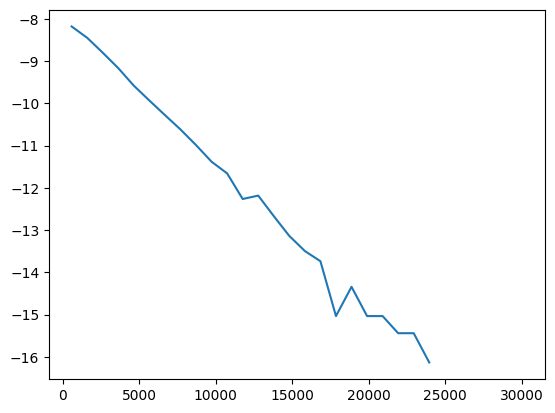

In [39]:
plt.plot(x,np.log(y))

In [ ]:
rs = np.linspace(0, 0.5, 20)
fp = []
for r in rs:
    fpt = fpt_dist(1000, 0, r, 10000)
    y,x = np.histogram(fpt, bins = 30, density = True)
    x = (x[:-1] + x[1:]) / 2
    fp.append(get_linreg_stats(x,y)["slope"])

In [ ]:
plt.plot(rs, pf)

# Mean First Passage Time
We study the dependance on the mean first passage time on $N, m_0, r$

In [3]:
Nvals = np.linspace(100,1000, 10)
m0vals = np.linspace(-1,1,21)
rvals = np.linspace(0,0.5, 21)

In [ ]:
for r in [0.01, 0.05, 0.1]:
    yN_sim = []
    yN_th = []
    for N in tqdm(Nvals):
        yN_sim.append(np.mean(fpt_dist(int(N), 0, r, 10000)))
        yN_th.append(fpt.mean_fpt(int(N), 0, r))
    
    yN_sim = np.array(yN_sim)
    yN_th = np.array(yN_th)
    
    plt.figure()
    
    plt.title(f"r = {r}")
    plt.xlabel("N")
    plt.ylabel("MFPT")
    
    plt.scatter(Nvals, yN_sim)
    plt.plot(Nvals, yN_th)
    plt.savefig(f"../figures/first_passage/MFPT_vs_N_r_{r}.pdf")

 60%|█████████████████████████████████████████████████▏                                | 6/10 [40:39<48:26, 726.71s/it]

In [ ]:
ym0_sim = []
ym0_th = []

for m0 in tqdm(m0vals):
    ym0_sim.append(np.mean(fpt_dist(500, m0, 0.1, 10000)))
    ym0_th.append(fpt.mean_fpt(500, m0, 0.1))
    
    ym0_sim = np.array(ym0_sim)
    ym0_th = np.array(ym0_th)

# plt.title(f"r = {r}")
plt.xlabel("m0")
plt.ylabel("MFPT")
    
plt.scatter(m0vals, ym0_sim)
plt.plot(m0vals, ym0_th)
plt.savefig("../figures/first_passage/MFPT_vs_m0.pdf")


# Gillespie Implementation

We try a Gillespie implementation of the simulation to accelerate it. We consider 3 events: resetting, and going up or down in magnetisation. Resetting has a fixed rate $r$ while the changes in magnetisation depend on the magnetisation itself, but we can see that they are equal:

$$ r_- = N\frac{n}{N}\frac{N-n}{N-1} = \frac{n(N-n)}{N-1} \qquad r_+ = N\frac{N-n}{N}\frac{n}{N-1} = \frac{n(N-n)}{N-1} $$

Where $N$ is the total number of nodes and $n$ is the number of nodes of state $+1$

So the total event rate is:

$$ \lambda = r + 2 \frac{n(N-n)}{N-1} $$

In [4]:
@njit
def first_passage_time_gillespie(N, m0, r):
    '''Takes:
    N: number of agents
    r: resetting rate per MC step
    m0: starting magnetisation   

        Returns:
    t/N: The first passage time to consensus'''

    # Initialize
    n = int(N*(m0+1)/2)  
    n_ini = n
    t = 0

    while n*(N-n) != 0:
        la = r/N + 2*( n*(N-n)/(N-1) )
        t += -np.log(np.random.random())/la

        if np.random.random() < r/N/la:
            n = n_ini

        else:
            if np.random.random() < 0.5:
                n += 1

            else:
                n += -1
    return(t)



@njit(parallel=True)
def fpt_dist_gillespie(N, m0, r, samples):
    """
    Returns the first passage time for many samplesç
    """
    res = np.zeros(samples)

    for i in prange(samples):
        res[i] = first_passage_time_gillespie(N, m0, r)        

    return res

### Distribution

In [62]:
N = 1000
m0 = 0
r = 0.1

fpt_d = fpt_dist_gillespie(N, m0, r, 10000)

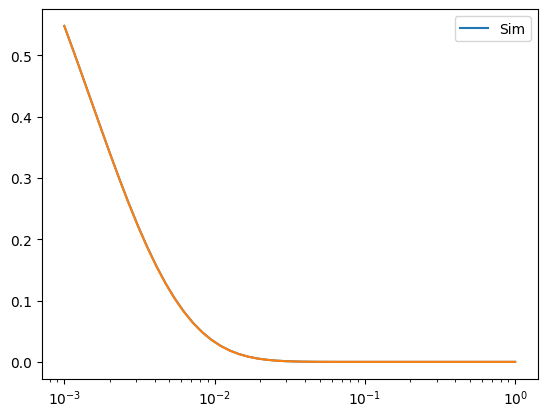

In [80]:
s_vals = np.logspace(-3, 0, 50)
laplace_vals = np.array([np.mean(np.exp(-s * fpt_d)) for s in s_vals])

# plt.yscale("log")
plt.xscale("log")
c1 = fpt.sol_fpt(N, m0, r, s_vals, M=10000)
c2 = fpt.sol_fpt(N, m0, r, s_vals, M=10001)
c3 = (np.array(c1) + np.array(c2))/2
plt.plot(s_vals, laplace_vals, label = "Sim")
plt.plot(s_vals, c3)

plt.legend()

In [81]:
Nvals = np.linspace(100,1000, 10)
m0vals = np.linspace(-1,1,21)
rvals = np.linspace(0,0.5, 21)

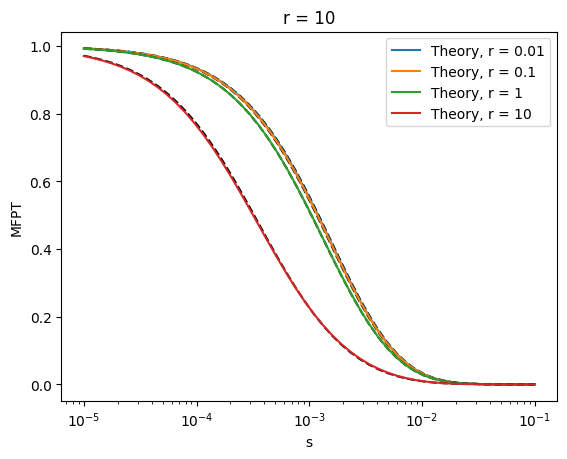

In [96]:
N = 1000
m0 = 0

for r in [0.01,  0.1, 1, 10]:
    s_vals = np.logspace(-5, -1, 50)
    fpt_d = fpt_dist_gillespie(N, m0, r, 10000)
    laplace_vals = np.array([np.mean(np.exp(-s * fpt_d)) for s in s_vals])

    # plt.figure()
    plt.xscale("log")
    plt.title(f"r = {r}")
    plt.xlabel("s")
    plt.ylabel("MFPT")
    
    c1 = fpt.sol_fpt(N, m0, r, s_vals, M=10000)
    c2 = fpt.sol_fpt(N, m0, r, s_vals, M=10001)
    c3 = (np.array(c1) + np.array(c2))/2
    
    plt.plot(s_vals, laplace_vals, "--k")
    plt.plot(s_vals, c3, label = f"Theory, r = {r}")
    plt.legend()

plt.savefig(f"../figures/first_passage/dist/dist_r_{r}.pdf")

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [06:06<00:00, 61.11s/it]


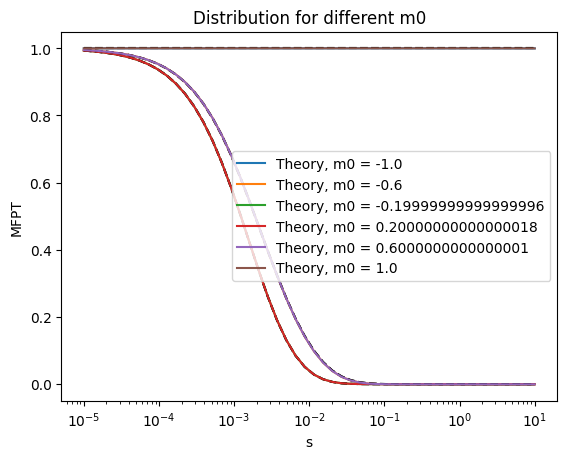

In [4]:
N = 1000
r = 0.1

for m0 in tqdm(np.linspace(-1, 1, 6)):
    s_vals = np.logspace(-5, 1, 50)
    fpt_d = fpt_dist_gillespie(N, m0, r, 10000)
    laplace_vals = np.array([np.mean(np.exp(-s * fpt_d)) for s in s_vals])

    # plt.figure()
    plt.xscale("log")
    plt.title(f"Distribution for different m0")
    plt.xlabel("s")
    plt.ylabel("MFPT")
    
    c1 = fpt.sol_fpt(N, m0, r, s_vals, M=10000)
    c2 = fpt.sol_fpt(N, m0, r, s_vals, M=10001)
    c3 = (np.array(c1) + np.array(c2))/2
    
    plt.plot(s_vals, laplace_vals, "--k")
    plt.plot(s_vals, c3, label = f"Theory, m0 = {m0}")
    plt.legend()

plt.savefig(f"../figures/first_passage/dist/dist_m0.pdf")

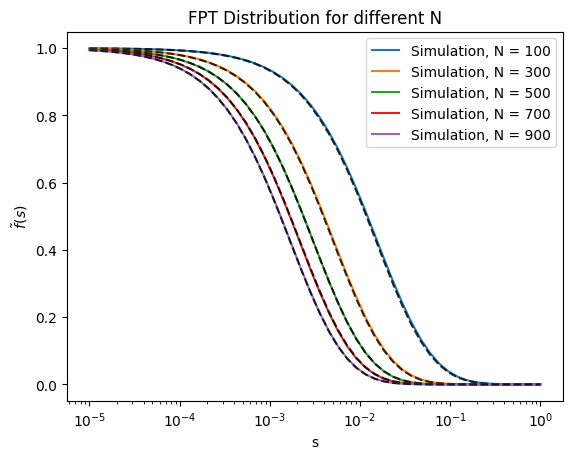

In [4]:
m0 = 0
r = 0.1

for N in [100,  300,  500,  700,  900]:
    s_vals = np.logspace(-5, 0, 50)
    fpt_d = fpt_dist_gillespie(N, m0, r, 10000)
    laplace_vals = np.array([np.mean(np.exp(-s * fpt_d)) for s in s_vals])

    # plt.figure()
    plt.xscale("log")
    plt.title(f"FPT Distribution for different N")
    plt.xlabel("s")
    plt.ylabel(r"$\tilde f(s)$")
    
    c1 = fpt.sol_fpt(N, m0, r, s_vals, M=10000)
    c2 = fpt.sol_fpt(N, m0, r, s_vals, M=10001)
    c3 = (np.array(c1) + np.array(c2))/2
    
    plt.plot(s_vals, laplace_vals, label = f"Simulation, N = {N}" )
    plt.plot(s_vals, c3, "--k", alpha = 0.8)
    plt.legend()

plt.savefig(f"../figures/first_passage/dist/dist_N.pdf")

### Mean

In [3]:
Nvals = np.linspace(100,1000, 10)
m0vals = np.linspace(-1,1,21)
rvals = np.linspace(0.5,10, 20)

In [ ]:
for r in [10]:
    yN_sim = []
    yN_th = []
    for N in tqdm(Nvals):
        yN_sim.append(np.mean(fpt_dist_gillespie(int(N), 0, r, 10000)))
        yN_th.append(fpt.mean_fpt(int(N), 0, r))
    
    yN_sim = np.array(yN_sim)
    yN_th = np.array(yN_th)
    
    plt.figure()
    
    plt.title(f"r = {r}")
    plt.xlabel("N")
    plt.ylabel("MFPT")
    
    plt.scatter(Nvals, yN_sim)
    plt.plot(Nvals, yN_th)
    plt.savefig(f"../figures/first_passage/MFPT_vs_N_r_{r}.pdf")

 40%|█████████████████████████████████▏                                                 | 4/10 [00:13<00:24,  4.07s/it]

In [ ]:
r = 0.5
N = 1000

ym0_sim = []
ym0_th = []
err_sim = []
err_th = []
ydv = []

for m0 in tqdm(m0vals):
    d = fpt_dist_gillespie(N, m0, r, 10000)
    dv = fpt_dist_gillespie(N, m0, 0, 10000)
    ym0_sim.append(np.mean(d))
    err_sim.append(np.std(d))
    ydv.append(np.mean(dv))
    ym0_th.append(fpt.mean_fpt(N, m0, r))
    err_th.append(fpt.variance_fpt(N, m0, r))

err_th[0] = 0
err_th[-1] = 0

In [ ]:
# 1. Setup the figure with a better aspect ratio and DPI
plt.figure(figsize=(8, 6), dpi=120)

# 2. Define colors for consistency
c_sim = '#2b7bba'  # A nice professional blue
c_th = '#d64045'   # A nice red/coral for contrast

# 3. Plot Simulation Data
# 'fmt="o"' creates dots instead of a line, which is better for discrete sim data
plt.errorbar(m0vals, ym0_sim, yerr=err_sim, 
             fmt='o', 
             color=c_sim, 
             ecolor=c_sim,       # Color of the error bars
             capsize=4,          # Size of the horizontal caps
             capthick=1.5,       # Thickness of caps
             elinewidth=1.5,     # Thickness of vertical error line
             markersize=6,       # Size of the dot
             label='Simulation',
             zorder=3,
             alpha = 0.8 )           # zorder=3 ensures dots sit ON TOP of the grid/lines

# 4. Plot Theory Data
plt.plot(m0vals, ym0_th, 
         color=c_th, 
         linestyle='--',     # Dashed line often indicates "theoretical prediction"
         linewidth=2, 
         label='Theory')

plt.plot(m0vals, ydv,  
         linestyle='--',
         color = "black", # Dashed line often indicates "theoretical prediction"
         linewidth=2, 
         label='VM')

# 5. Plot Theory Error Bounds
# Ensure inputs are numpy arrays for element-wise addition
y_th_arr = np.array(ym0_th)
e_th_arr = np.array(err_th)

plt.fill_between(m0vals, y_th_arr + e_th_arr, y_th_arr - e_th_arr, 
                 color=c_th, 
                 alpha=0.15,       # Transparency
                 edgecolor=None,
                 label=r"$\pm\sigma$")   # Remove hard border on the fill

# 6. Labels, Title, and Legend
# Using r'...' allows LaTeX formatting for math symbols like m_0
plt.xlabel(r'$m_0$', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)
plt.title(f'MFPT vs $m_0$ at Polarizing Rate $r = {r}$', fontsize=14, pad=15)

plt.legend(frameon=True, fontsize=11, loc='best', fancybox=True, framealpha=0.9)

# 7. Grid and Layout

plt.tight_layout()

# Save
plt.savefig(f"../figures/first_passage/MFPT_vs_m0_r_{r}.pdf", bbox_inches='tight')
plt.show()

# Exp-log comparisson

In [11]:
rvals = np.linspace(0.5,10, 20)
N = 500
m0 = 0

yr_sim = []
# yr_th = []
# err_sim = []
# err_th = []

for r in tqdm(rvals):
    d = fpt_dist_gillespie(N, m0, r, 10000)
    yr_sim.append(np.mean(d))
    # err_sim.append(np.std(d))
    # yr_th.append(fpt.mean_fpt(N, m0, r))
    # err_th.append(fpt.variance_fpt(N, m0, r))


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [02:15<00:00,  6.77s/it]


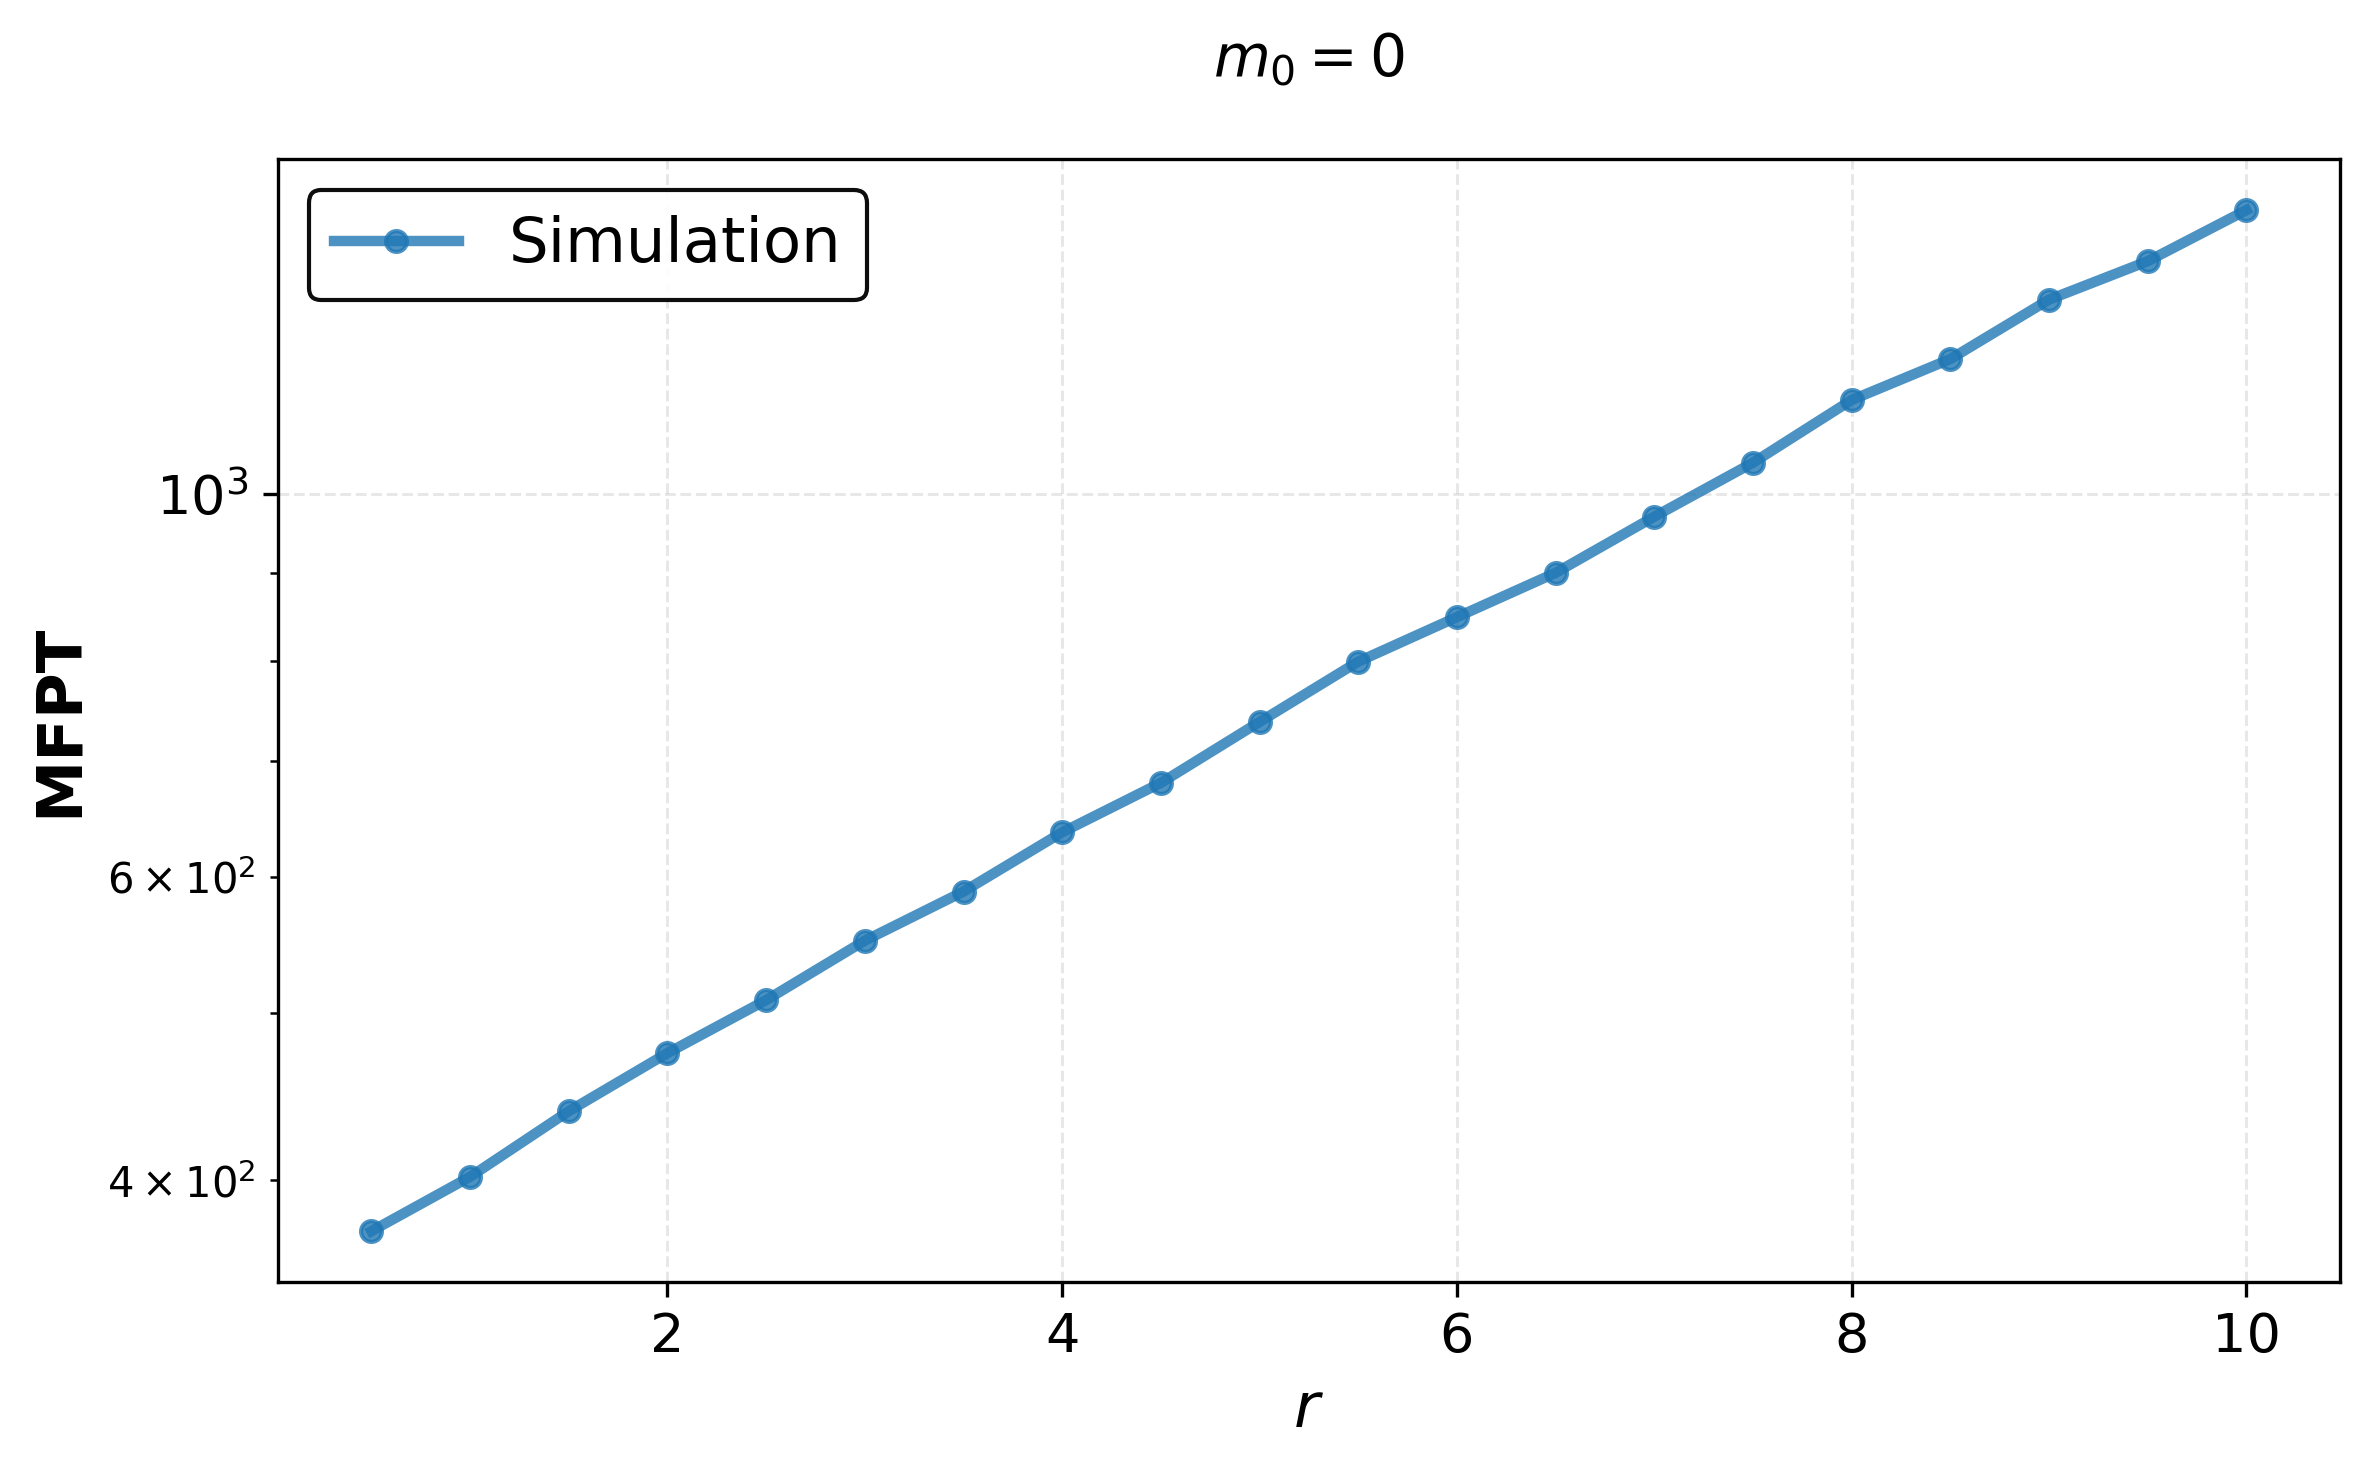

In [17]:
# Create figure with better size and DPI
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Plot with improved styling
ax.plot(rvals, yr_sim, label="Simulation", linewidth=2.5, color='#1f77b4', marker='o', markersize=5, alpha=0.8)

# Enhanced labels and title
ax.set_xlabel(r"$r$", fontsize=15, fontweight='bold')
ax.set_ylabel("MFPT", fontsize=15, fontweight='bold')
ax.set_title(r"$m_0 = 0$", fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='both', which='major', labelsize=13)

# Better scale and grid
ax.set_yscale("log")
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Improved legend
ax.legend(fontsize=15, framealpha=0.95, loc='best', edgecolor='black')

# Tighter layout
plt.tight_layout()

# Save with high quality
plt.savefig(f"../../figures/first_passage/MFPT_vs_r_0.pdf", dpi=300, bbox_inches='tight')


In [20]:
rvals = np.linspace(0.5,10, 20)
N = 500
m0 = 1-1/N

yr_sim2 = []


for r in tqdm(rvals):
    d = fpt_dist_gillespie(N, m0, r, 1000000)
    yr_sim2.append(np.mean(d))
    

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.59it/s]


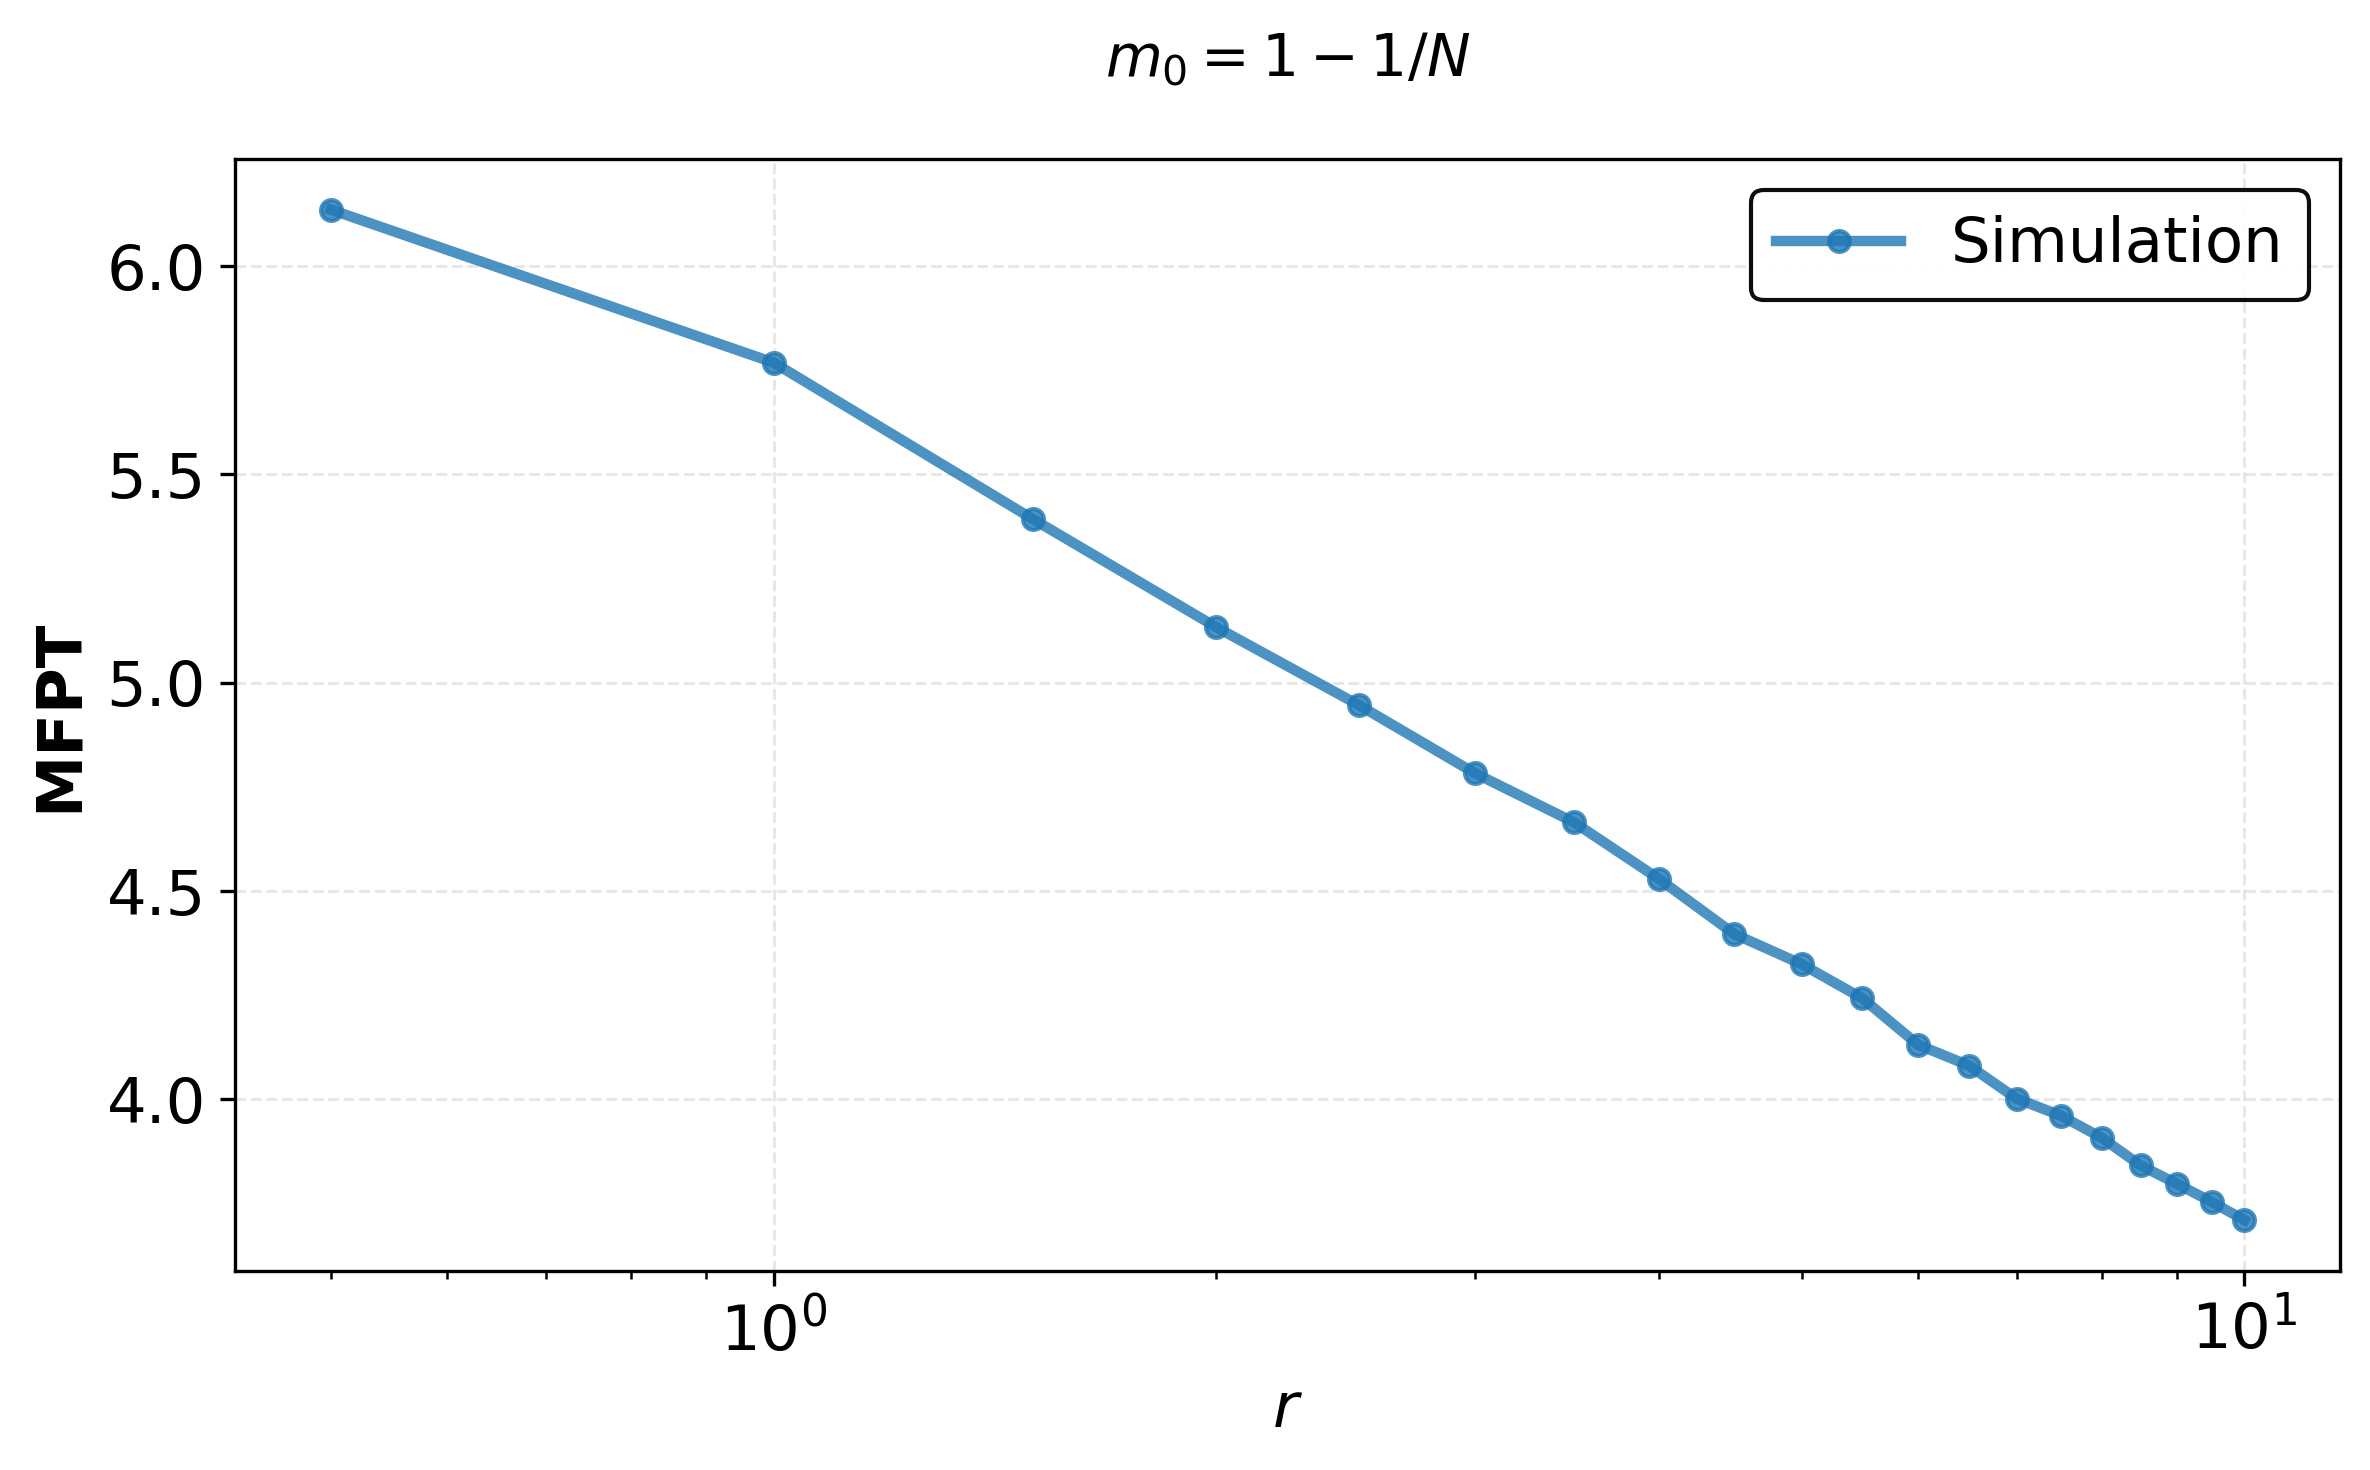

In [26]:
# Create figure with better size and DPI
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Plot with improved styling
ax.plot(rvals, yr_sim2, label="Simulation", linewidth=2.5, color='#1f77b4', marker='o', markersize=5, alpha=0.8)

# Enhanced labels and title
ax.set_xlabel(r"$r$", fontsize=15, fontweight='bold')
ax.set_ylabel("MFPT", fontsize=15, fontweight='bold')
ax.set_title(r"$m_0 = 1-1/N$", fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='both', which='major', labelsize=15)

# Better scale and grid
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Improved legend
ax.legend(fontsize=15, framealpha=0.95, loc='best', edgecolor='black')

# Tighter layout
plt.tight_layout()

# Save with high quality
plt.savefig(f"../../figures/all_to_all/first_passage/MFPT_vs_r/MFPT_vs_r_1.pdf", dpi=300, bbox_inches='tight')


In [ ]:
rvals = np.linspace(0.5,10, 20)
N = 500

for m0 in np.linspace(0,1-1/N,10):
    yr_sim = []
    
    for r in tqdm(rvals):
        d = fpt_dist_gillespie(N, m0, r, 10000)
        yr_sim.append(np.mean(d))

    # Create figure with better size and DPI
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    
    # Plot with improved styling
    ax.plot(rvals, yr_sim2, label="Simulation", linewidth=2.5, color='#1f77b4', marker='o', markersize=5, alpha=0.8)
    
    # Enhanced labels and title
    ax.set_xlabel(r"$r$", fontsize=15, fontweight='bold')
    ax.set_ylabel("MFPT", fontsize=15, fontweight='bold')
    ax.set_title(fr"$m_0 = {m0}$", fontsize=14, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    
    # Better scale and grid
    # ax.set_xscale("log")
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    
    # Improved legend
    ax.legend(fontsize=15, framealpha=0.95, loc='best', edgecolor='black')
    
    # Tighter layout
    plt.tight_layout()
    
    # Save with high quality
    plt.savefig(f"../../figures/all_to_all/first_passage/MFPT_vs_r/MFPT_vs_r_{m0}.pdf", dpi=300, bbox_inches='tight')
    

 25%|████████████████████▊                                                              | 5/20 [01:09<03:32, 14.19s/it]